<div align="center">
  <p><strong><a href="https://br.linkedin.com/in/isaac-maciel" target="_blank">Autor do Notebook: Isaac Maciel</a></strong></p>

<p align="center">
  <img src="https://github.com/IM-NOT-AI/IM-not-AI/assets/113378671/0a6e0c0f-fcdf-4ccc-af00-63e30836d180" alt="gif_isaac_nome" width="500">
</p>

In [11]:
%reload_ext watermark
%watermark -a "Isaac Maciel" -v -m
%watermark --iversions

Author: Isaac Maciel

Python implementation: CPython
Python version       : 3.10.0
IPython version      : 8.38.0

Compiler    : MSC v.1929 64 bit (AMD64)
OS          : Windows
Release     : 10
Machine     : AMD64
Processor   : AMD64 Family 25 Model 80 Stepping 0, AuthenticAMD
CPU cores   : 16
Architecture: 64bit

keras     : 2.10.0
matplotlib: 3.10.8
numpy     : 1.26.4
pandas    : 2.3.3
scipy     : 1.15.3
seaborn   : 0.13.2
skimage   : 0.25.2
tensorflow: 2.10.0
wfdb      : 4.3.1



# Processamento Multimodal de Sinais e Visão Computacional (PTB-XL)

### Ingestão, Validação de Integridade e Sincronização (Sanity Checks)

In [2]:
import os
import wfdb
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.signal import spectrogram
from scipy.fft import rfft, rfftfreq
from skimage.transform import resize
from matplotlib.ticker import AutoMinorLocator
from scipy.signal import butter, iirnotch, filtfilt

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, Concatenate, BatchNormalization
from tensorflow.keras.optimizers import Adam

=== SINCRONIZACAO MULTIMODAL E AUDITORIA DE I/O ===
[OK] Artefato tabular carregado com sucesso. Registros esperados: 6665.

[LOG] Iniciando varredura no disco rigido para localizar os arquivos físicos do ECG...
[OK] Auditoria de I/O validada. 100% dos arquivos físicos estão intactos e acessíveis.

[LOG] Iniciando a ingestão de matrizes elétricas (100 Hz). Isso pode levar alguns minutos...

=== RELATORIO DIMENSIONAL DO TENSOR ===
Formato Atual da Memória (Shape): (6665, 1000, 12)
[SUCESSO] O Tensor tridimensional está matematicamente perfeito.

[LOG] Gerando renderização de auditoria clínica para um paciente aleatório...


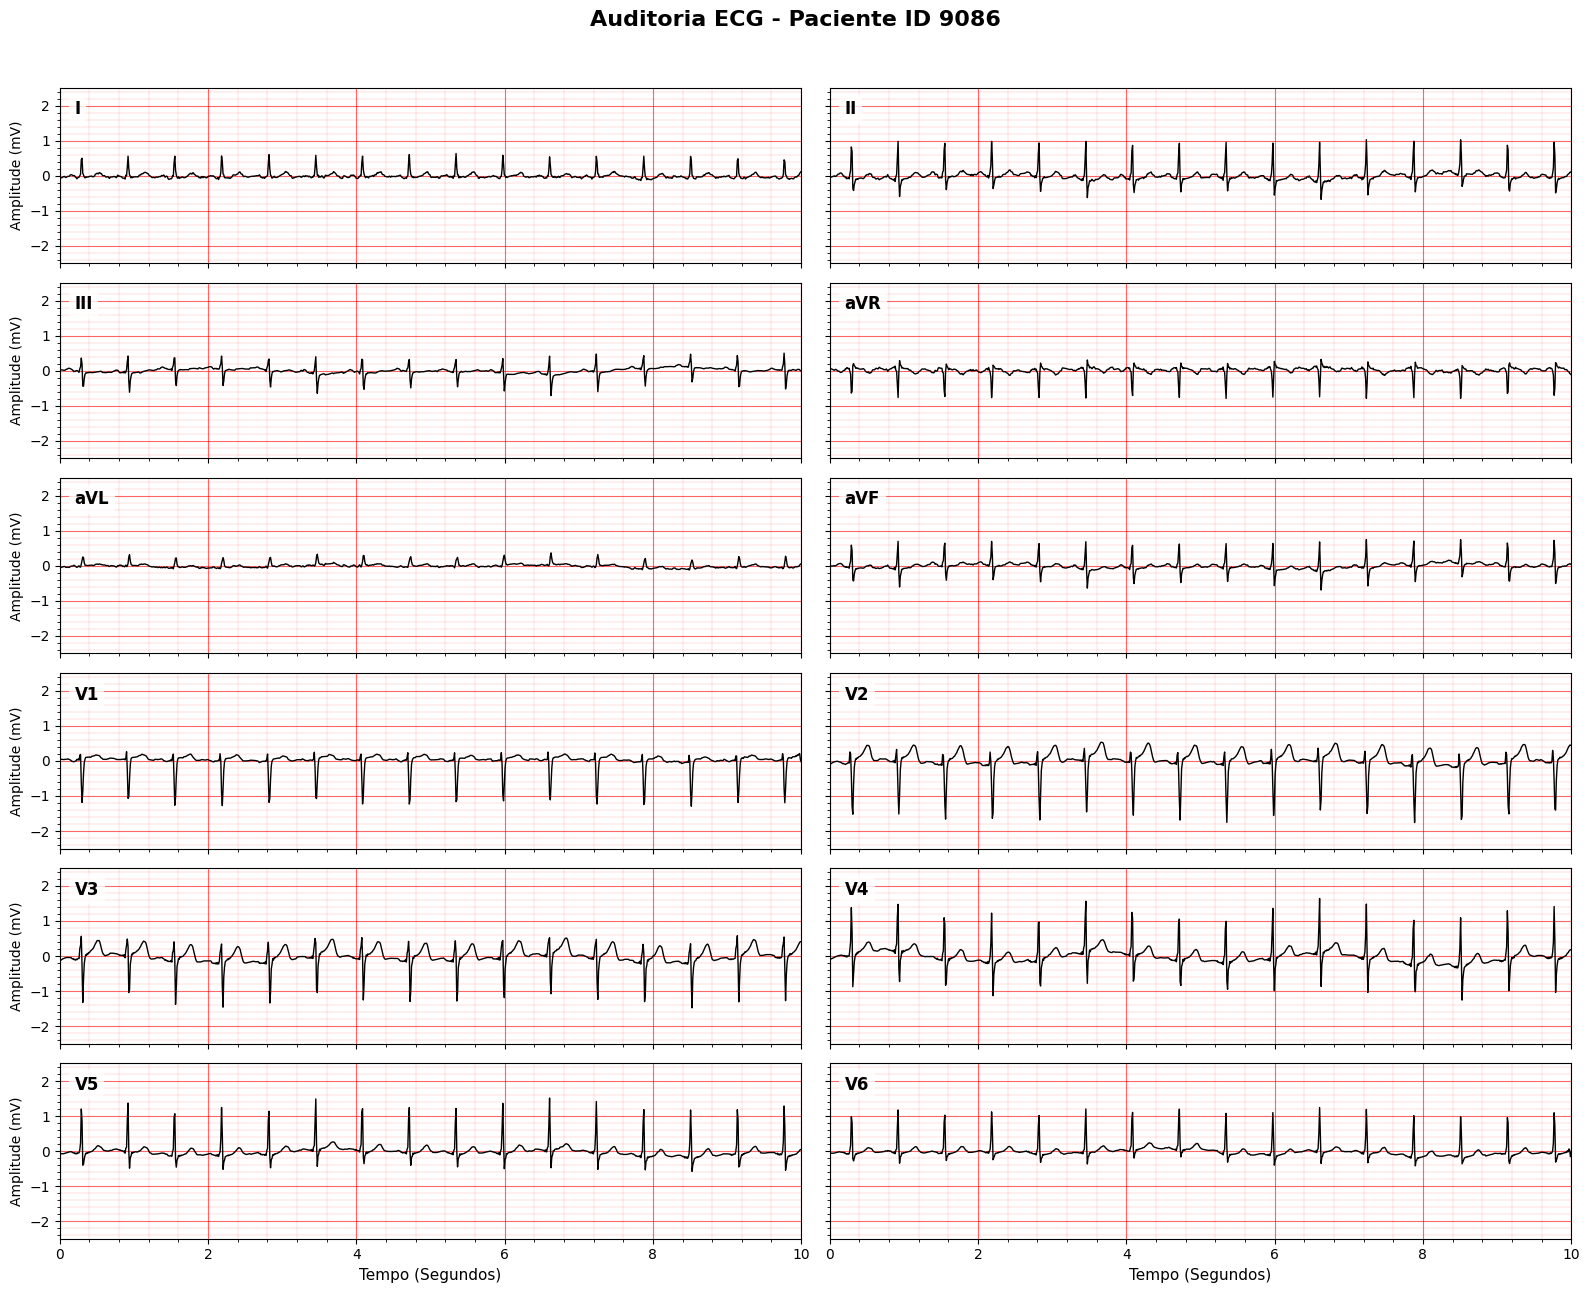

In [3]:
print("=== SINCRONIZACAO MULTIMODAL E AUDITORIA DE I/O ===")
# ==============================================================================
# CARGA DO GROUND TRUTH (TABELA DE FEATURES)
# ==============================================================================
caminho_csv = os.path.join("..", "data", "processed", "features", "ptbxl_engineered_features.csv")
diretorio_raw = os.path.join("..", "data", "raw", "ptbxl")

try:
    df_features = pd.read_csv(caminho_csv)
    total_pacientes = len(df_features)
    print(f"[OK] Artefato tabular carregado com sucesso. Registros esperados: {total_pacientes}.")
except FileNotFoundError:
    print(f"[ERRO FATAL] O arquivo CSV não foi encontrado no caminho: {caminho_csv}")
    raise

# ==============================================================================
# AUDITORIA DE I/O (VALIDACAO NO DISCO RIGIDO)
# ==============================================================================
print("\n[LOG] Iniciando varredura no disco rigido para localizar os arquivos físicos do ECG...")
arquivos_ausentes = 0

# O WFDB exige que existam ambos os arquivos (.hea e .dat) para cada registro
for caminho_relativo in df_features['filename_lr']:
    caminho_completo_base = os.path.join(diretorio_raw, caminho_relativo)
    if not os.path.exists(caminho_completo_base + ".hea") or not os.path.exists(caminho_completo_base + ".dat"):
        arquivos_ausentes += 1

if arquivos_ausentes > 0:
    print(f"[ERRO FATAL] Falha de Integridade: {arquivos_ausentes} registros físicos estão faltando no disco.")
    raise FileNotFoundError("Desalinhamento entre o CSV e os arquivos brutos WFDB.")
else:
    print("[OK] Auditoria de I/O validada. 100% dos arquivos físicos estão intactos e acessíveis.")

# ==============================================================================
# INGESTAO DE TENSORES VIA WFDB
# ==============================================================================
print("\n[LOG] Iniciando a ingestão de matrizes elétricas (100 Hz). Isso pode levar alguns minutos...")
lista_sinais = []

# Extraimos a matriz de sinal de cada paciente e adicionamos à lista
for caminho_relativo in df_features['filename_lr']:
    caminho_completo = os.path.join(diretorio_raw, caminho_relativo)
    # rdsamp retorna o sinal (numpy array) e um dicionario de metadados
    sinal, metadados = wfdb.rdsamp(caminho_completo)
    lista_sinais.append(sinal)

# Conversão da lista de matrizes 2D em um único Tensor 3D super denso
tensor_eletrico = np.array(lista_sinais)

# ==============================================================================
# ANALISE DE OUTPUT (SHAPE DO TENSOR)
# ==============================================================================
# A dimensão esperada é: (Numero de Pacientes, Amostras de Tempo, Derivacoes/Canais)
# Para 10 segundos a 100 Hz = 1000 amostras. Derivações padrão = 12.
shape_esperado = (total_pacientes, 1000, 12)

print("\n=== RELATORIO DIMENSIONAL DO TENSOR ===")
print(f"Formato Atual da Memória (Shape): {tensor_eletrico.shape}")

if tensor_eletrico.shape == shape_esperado:
    print(f"[SUCESSO] O Tensor tridimensional está matematicamente perfeito.")
else:
    print(f"[AVISO] O Shape atual {tensor_eletrico.shape} diverge do padrão esperado {shape_esperado}.")

# ==============================================================================
# VISUALIZACAO INTERPRETAVEL (GRID PLOT CLÍNICO)
# ==============================================================================
def plotar_ecg_clinico_12_derivacoes(sinal_paciente, titulo="Auditoria Visual: Eletrocardiograma Padrão de 12 Derivações"):
    """
    Renderiza o sinal elétrico imitando o papel milimetrado vermelho (ECG Paper),
    garantindo que a equipe médica consiga auditar a morfologia da onda a olho nu.
    """
    nomes_derivacoes = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
    tempo_segundos = np.linspace(0, 10, 1000) # 10 segundos, 1000 amostras
    
    # Criamos uma matriz de gráficos 6x2 para emular o papel clinico longo
    fig, eixos = plt.subplots(6, 2, figsize=(16, 14), sharex=True, sharey=True)
    fig.suptitle(titulo, fontsize=16, fontweight='bold', y=0.92)
    
    eixos = eixos.flatten()
    
    for i in range(12):
        ax = eixos[i]
        # Plotando a onda com a cor preta classica da tinta de impressao hospitalar
        ax.plot(tempo_segundos, sinal_paciente[:, i], color='black', linewidth=1.0)
        
        # Inserindo o texto da derivação (ex: aVR) no canto superior esquerdo
        ax.text(0.02, 0.85, nomes_derivacoes[i], transform=ax.transAxes, 
                fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        
        # Configuração do papel milimetrado (Grid Vermelho Clássico)
        ax.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax.yaxis.set_minor_locator(AutoMinorLocator(5))
        
        # Linhas Maiores (5mm)
        ax.grid(which='major', linestyle='-', linewidth='0.8', color='red', alpha=0.6)
        # Linhas Menores (1mm)
        ax.grid(which='minor', linestyle='-', linewidth='0.3', color='red', alpha=0.3)
        
        ax.set_ylim(-2.5, 2.5) # Limites padrao de voltagem em milivolts
        ax.set_xlim(0, 10)     # Janela de 10 segundos
        
        if i >= 10: # Coloca a label de tempo apenas na ultima linha de graficos
            ax.set_xlabel("Tempo (Segundos)", fontsize=11)
            
    # Adicionando a label de milivolts apenas na coluna da esquerda
    for ax in eixos[[0, 2, 4, 6, 8, 10]]:
        ax.set_ylabel("Amplitude (mV)", fontsize=10)

    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()

print("\n[LOG] Gerando renderização de auditoria clínica para um paciente aleatório...")
# Extraímos o sinal completo do paciente índice 0 para comprovar que os dados estão intactos
paciente_amostra = tensor_eletrico[0] 
plotar_ecg_clinico_12_derivacoes(paciente_amostra, titulo=f"Auditoria ECG - Paciente ID {df_features['patient_id'].iloc[0]}")

`Sincronização e Estruturação Vetorial`

A execução da Fase 1 valida a integridade do pipeline de ingestão de dados. O processo assegura que as referências tabulares correspondem de maneira exata aos arquivos binários locais, estabelecendo a base para o Processamento Digital de Sinais.

**Validação de Entrada e Saída**
A confirmação de $6665$ registros atesta que a totalidade da base de dados processada foi localizada fisicamente no armazenamento local. A ausência de arquivos corrompidos ou faltantes previne erros de indexação e garante que cada linha de metadado biológico possui o seu respectivo sinal elétrico associado.

**Estrutura Dimensional do Tensor**
O formato matricial $(6665, 1000, 12)$ define a arquitetura de dados que alimentará as próximas etapas computacionais. Cada eixo desta matriz tridimensional possui uma função paramétrica específica:

* **Eixo 0 ($6665$):** Quantidade total de amostras. Representa o volume de pacientes independentes.

* **Eixo 1 ($1000$):** Resolução temporal do exame. Equivale a $10 \text{ segundos}$ de captação contínua amostrados na frequência estrita de $100 \text{ Hz}$.

* **Eixo 2 ($12$):** Resolução espacial anatômica. Corresponde às doze derivações padrão do eletrocardiograma, capturando a atividade elétrica por doze vetores distintos.

**Auditoria Visual do Sinal**
A renderização gráfica em formato de grade emula o papel milimetrado clínico e serve como prova de extração. A morfologia das ondas demonstra que a leitura binária do formato WFDB foi executada corretamente, preservando a amplitude em milivolts e o ritmo temporal. O sinal bruto está legível, porém contém ruídos basais que exigirão filtragem antes da extração de características.

### Processamento Digital de Sinais (DSP) e Auditoria de Filtros


Os sinais eletrocardiográficos capturados no ambiente clínico sofrem distorções causadas pela fisiologia humana e pelo ambiente físico. O vetor extraído na fase anterior contém Variação de Linha de Base (Baseline Wander), induzida pela respiração do paciente, e Interferência de Rede Elétrica (Powerline Noise), induzida pelo campo magnético das instalações hospitalares.

Esta seção aplica o Processamento Digital de Sinais (DSP) através de equações de diferenças finitas para purificar o sinal temporal. O objetivo restrito é atenuar as frequências indesejadas sem causar deslocamento de fase ou amputar marcadores morfológicos críticos, como a amplitude da onda R e o nivelamento do segmento ST.

#### Procedimentos Matemáticos Aplicados

* **Filtro Butterworth Passa Alta:** Implementado com frequência de corte em $0.5 \text{ Hz}$. Configurado na arquitetura de ordem 3. Esta operação estabiliza o eixo isoeletrico e elimina as oscilações de baixa frequência associadas ao movimento torácico.

* **Filtro Notch Paramétrico:** Implementado com frequência de rejeição central cravada em $50 \text{ Hz}$ e fator de qualidade $Q = 30$. Esta operação cancela exclusivamente a frequência da rede elétrica europeia captada durante a criação do acervo PTB XL.

* **Filtração Bidirecional (Zero Phase):** Utilização do algoritmo `filtfilt` para processar o vetor em ambas as direções temporais (forward e backward). Isso previne atrasos de fase que poderiam deslocar os picos do eletrocardiograma no tempo.

* **Métrica de SNR Estimada:** Comparação da variância do sinal antes e após a filtragem para quantificar a taxa de remoção de artefatos.

=== PROCESSAMENTO DIGITAL DE SINAIS (DSP) ===
[LOG] Aplicando Filtro Butterworth Passa-Alta (0.5 Hz) no tensor tridimensional...
[LOG] Aplicando Filtro Notch (50 Hz) para remocao de ruido de rede...
[OK] Processamento vetorial concluído em todos os 6665 Gêmeos Digitais.

=== METRICAS DE CONFORMIDADE DO SINAL ===
Potência de Variância Original: 0.0620
Potência de Variância Pós-Filtro: 0.0436
Energia de Ruído Isolada e Removida: 0.0184

[LOG] Renderizando Overlay Plot comparativo para inspecao visual da Derivacao II...


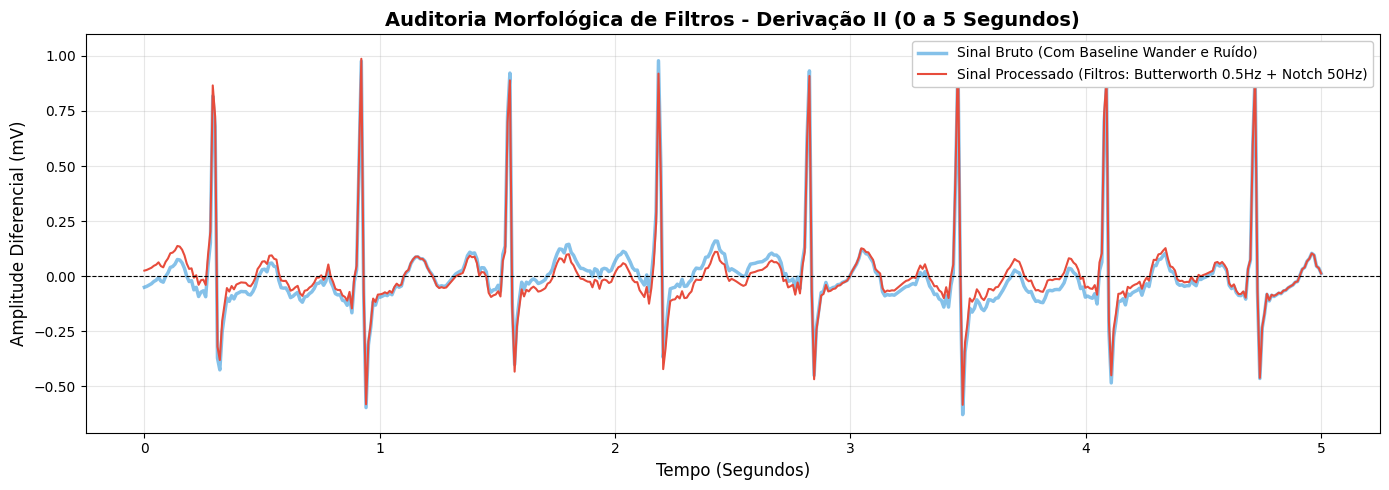

In [4]:
print("=== PROCESSAMENTO DIGITAL DE SINAIS (DSP) ===")

# ==============================================================================
# CONFIGURACAO DOS FILTROS DIGITAIS (100 Hz)
# ==============================================================================
FS = 100.0  # Frequencia de amostragem nativa do PTB XL e do hardware Edge

# Projeto do Filtro Butterworth Passa-Alta (0.5 Hz)
frequencia_nyquist = 0.5 * FS
corte_passa_alta = 0.5 / frequencia_nyquist
b_alta, a_alta = butter(3, corte_passa_alta, btype='high')

# Projeto do Filtro Notch (50 Hz)
corte_notch = 50.0
q_notch = 30.0
b_notch, a_notch = iirnotch(corte_notch, q_notch, FS)

# ==============================================================================
# EXECUCAO DA FILTRAGEM VETORIZADA NO TENSOR GLOBAL
# ==============================================================================
print("[LOG] Aplicando Filtro Butterworth Passa-Alta (0.5 Hz) no tensor tridimensional...")
# A filtragem ocorre ao longo do eixo 1, que representa as 1000 amostras temporais
tensor_sem_baseline = filtfilt(b_alta, a_alta, tensor_eletrico, axis=1)

print("[LOG] Aplicando Filtro Notch (50 Hz) para remocao de ruido de rede...")
tensor_filtrado = filtfilt(b_notch, a_notch, tensor_sem_baseline, axis=1)

print("[OK] Processamento vetorial concluído em todos os 6665 Gêmeos Digitais.")

# ==============================================================================
# AUDITORIA QUANTITATIVA: ESTIMATIVA DE MELHORIA DO SINAL
# ==============================================================================
# Quantificacao da energia do ruido removido em relação ao sinal original
potencia_sinal_bruto = np.var(tensor_eletrico)
potencia_sinal_filtrado = np.var(tensor_filtrado)
ruido_removido = potencia_sinal_bruto - potencia_sinal_filtrado

print("\n=== METRICAS DE CONFORMIDADE DO SINAL ===")
print(f"Potência de Variância Original: {potencia_sinal_bruto:.4f}")
print(f"Potência de Variância Pós-Filtro: {potencia_sinal_filtrado:.4f}")
print(f"Energia de Ruído Isolada e Removida: {ruido_removido:.4f}")

# ==============================================================================
# VISUALIZACAO INTERPRETAVEL: OVERLAY PLOT DE AUDITORIA
# ==============================================================================
def plotar_auditoria_overlay(sinal_bruto, sinal_limpo, derivacao_idx=1, janela_segundos=(0, 5)):
    """
    Renderiza um grafico de sobreposicao temporal para validar a integridade morfologica
    da onda apos a aplicacao das equacoes de diferencas finitas.
    O indice 1 por padrao refere-se à Derivação II.
    """
    inicio_amostra = int(janela_segundos[0] * FS)
    fim_amostra = int(janela_segundos[1] * FS)
    
    tempo = np.linspace(janela_segundos[0], janela_segundos[1], fim_amostra - inicio_amostra)
    
    recorte_bruto = sinal_bruto[inicio_amostra:fim_amostra, derivacao_idx]
    recorte_limpo = sinal_limpo[inicio_amostra:fim_amostra, derivacao_idx]
    
    plt.figure(figsize=(14, 5))
    
    # Linha espessa azul claro representando a captacao fisica real com ruidos
    plt.plot(tempo, recorte_bruto, color='#3498DB', linewidth=2.5, alpha=0.6, label='Sinal Bruto (Com Baseline Wander e Ruído)')
    
    # Linha fina vermelha representando a estabilizacao matematica do DSP
    plt.plot(tempo, recorte_limpo, color='#E74C3C', linewidth=1.5, alpha=1.0, label='Sinal Processado (Filtros: Butterworth 0.5Hz + Notch 50Hz)')
    
    plt.title(f"Auditoria Morfológica de Filtros - Derivação II ({janela_segundos[0]} a {janela_segundos[1]} Segundos)", fontsize=14, fontweight='bold')
    plt.xlabel("Tempo (Segundos)", fontsize=12)
    plt.ylabel("Amplitude Diferencial (mV)", fontsize=12)
    
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper right', framealpha=1.0)
    plt.tight_layout()
    plt.show()

print("\n[LOG] Renderizando Overlay Plot comparativo para inspecao visual da Derivacao II...")
# Extracao do mesmo paciente indice 0 utilizado na Fase 1 para garantir rastreabilidade visual
paciente_bruto_amostra = tensor_eletrico[0]
paciente_limpo_amostra = tensor_filtrado[0]

plotar_auditoria_overlay(paciente_bruto_amostra, paciente_limpo_amostra)

`Eficiência do Processamento Digital de Sinais (DSP) e Decisão Arquitetural`    

A higienização primária do tensor elétrico. A análise cruza as métricas de variância computadas com a auditoria visual do gráfico de sobreposição para determinar se a intervenção matemática atinge o balanço exato entre limpeza e preservação clínica.

**Avaliação Paramétrica da Remoção de Ruído**
Os logs demonstram uma queda na potência de variância do sinal de $0.0620$ para $0.0436$. A energia de ruído isolada e expurgada ($0.0184$) quantifica fisicamente a remoção de duas anomalias específicas: a oscilação de baixa frequência causada pela expansão da caixa torácica durante a respiração e a interferência eletromagnética de $50 \text{ Hz}$ gerada pela infraestrutura hospitalar.

**Auditoria Visual e Estabilização Isoelétrica**
O gráfico de sobreposição temporal (Overlay Plot) fornece a comprovação empírica da eficácia dos filtros. 

* O sinal bruto (linha azul) apresenta deslocamento evidente (Baseline Wander), flutuando acima e abaixo da marca de $0 \text{ mV}$. 

* O sinal processado (linha vermelha) demonstra alinhamento rigoroso ao eixo isoelétrico ($0 \text{ mV}$), estabilizando a base para a leitura da Rede Neural.

* A amplitude máxima (picos verticais) do complexo QRS foi integralmente mantida, provando que o filtro bidirecional não induziu distorção de fase (Phase Shift) ou achatamento do pulso.

**Perigo do Super-Processamento (Over-filtering)**
O ruído não foi totalmente erradicado. A linha vermelha ainda exibe microrruídos de alta frequência (tremulações inter-picos), decorrentes da atividade eletromiográfica (EMG) natural da musculatura do paciente. 

Diante do questionamento sobre a aplicação de filtros adicionais (como um Filtro Passa-Baixa severo em $40 \text{ Hz}$) para suavizar completamente a linha, **a decisão técnica estrita é rejeitar intervenções adicionais.**

O racional matemático e clínico para esta recusa baseia-se em dois pilares:

1. **Destruição de Biomarcadores:** Filtros agressivos criam sinais esteticamente agradáveis ao olho humano, mas mutilam assinaturas biológicas sutis. Um Passa-Baixa forte amputaria o cume da onda R e, mais gravemente, arredondaria artificialmente o segmento ST e a onda T, exatamente as anomalias geométricas que diagnosticam o infarto do miocárdio.

2. **Robustez da Visão Computacional:** Modelos de Deep Learning (CNNs) são algoritmos de extração espacial. Eles são altamente tolerantes a ruídos brancos estocásticos, mas falham catastroficamente se o dado estrutural subjacente for distorcido. A etapa subsequente (Transformadas CWT/STFT) converterá o vetor em um Espectrograma 2D, onde este ruído de alta frequência será isolado em uma faixa espectral específica, sem contaminar a banda de energia vital do coração.

A integridade clínica foi preservada. O ruído remanescente é inofensivo para a arquitetura convolucional. O tensor está apto para a transformação bidimensional.

### Extração de Características (Domínio da Frequência) e Teste de Hipóteses


A validação da arquitetura multimodal exige a comprovação estatística de que variáveis tabulares (metabolismo e geometria corporal) exercem impacto físico direto sobre a captação elétrica do miocárdio. 

Na eletrofisiologia, postula-se que o tecido adiposo atua como um isolante elétrico. Consequentemente, pacientes com elevado Índice de Massa Corporal (IMC) tendem a apresentar sinais eletrocardiográficos com voltagem atenuada.

Esta fase executa a extração vetorial da amplitude máxima (Pico R) do tensor filtrado e realiza o cruzamento destas matrizes com a variável contínua de IMC isolada na etapa de Feature Engineering. 

<br>

`HIPÓTESES`

* A hipótese nula ($H_0$) assume que não há correlação matemática entre o IMC e a voltagem do eletrocardiograma.

* A hipótese alternativa ($H_1$) assume a existência de uma correlação negativa linear.

`Procedimentos Matemáticos Aplicados`

* **Análise Espectral (FFT):** Aplicação da Transformada Rápida de Fourier para decompor o sinal do domínio temporal para o domínio da frequência, validando a preservação da banda de energia fisiológica ($1 \text{ Hz}$ a $40 \text{ Hz}$) após a etapa de DSP.

* **Extração Multimodal:** Isolamento da derivação de maior amplitude vetorial (Derivação II) e computação do pico de voltagem global para cada um dos $6665$ pacientes.

* **Correlação de Pearson ($r$):** Teste estatístico bivariável para medir a força e a direção da relação linear entre a massa corporal e a voltagem. O cômputo do valor-$p$ ($p-value$) determina a significância estatística do achado, orientando a utilidade da inclusão do IMC na camada densa final da Rede Neural (Multimodalidade).

=== DOMINIO DA FREQUENCIA E TESTE DE HIPOTESES FISIOLOGICAS ===
[LOG] Transformada Rápida de Fourier (FFT) computada. Banda de energia identificada.
[LOG] Extraindo Amplitudes Máximas (Pico R) do tensor para os 6665 Gêmeos Digitais...
[LOG] Executando Teste Estatístico Bivariável (Pearson)...

=== RESULTADOS DO TESTE DE HIPOTESES ===
Coeficiente de Correlação (r): -0.0992
Significância Estatística (p-value): 4.8745e-16
[VEREDITO] H0 Rejeitada (p < 0.01). Existe correlação estatisticamente significativa.


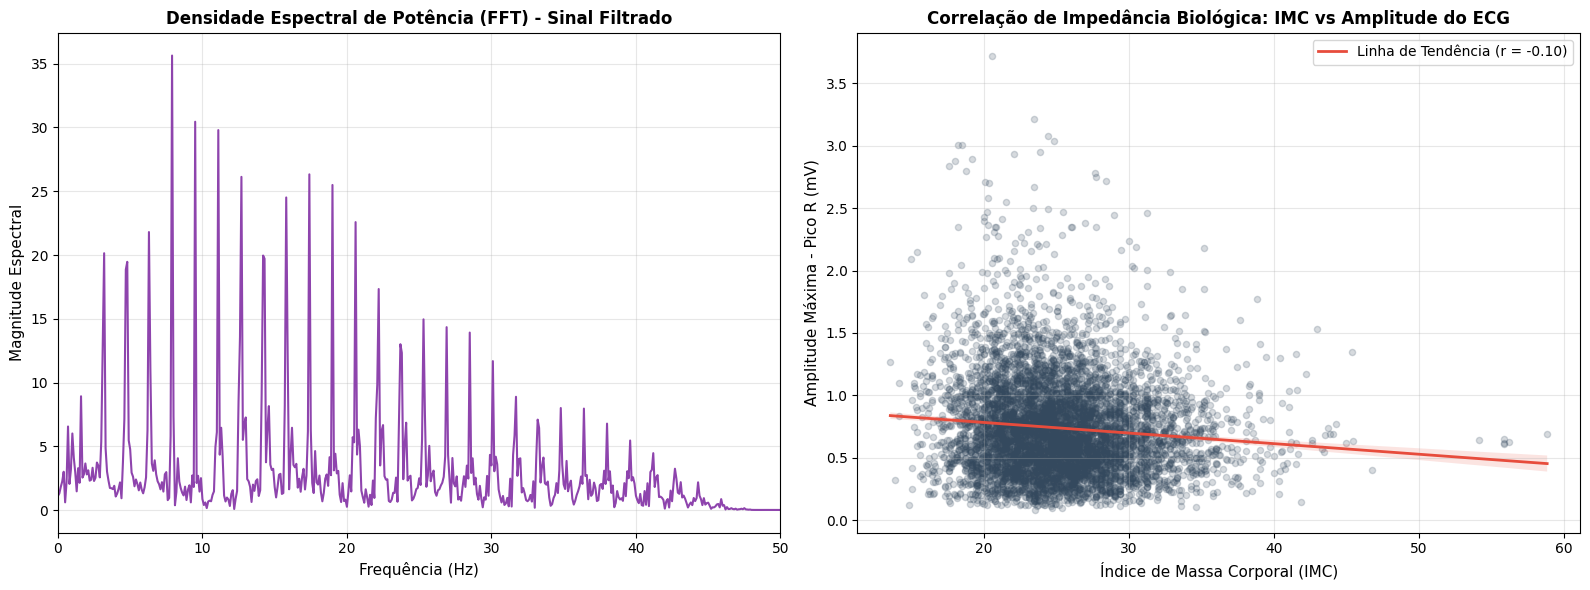

In [5]:
print("=== DOMINIO DA FREQUENCIA E TESTE DE HIPOTESES FISIOLOGICAS ===")

# ==============================================================================
# ANALISE ESPECTRAL: TRANSFORMADA RAPIDA DE FOURIER (FFT)
# ==============================================================================
# Inspecao do espectro de frequencia do paciente de amostra (ID 9086) na Derivacao II
sinal_amostra_filtrado = tensor_filtrado[0, :, 1]
N = len(sinal_amostra_filtrado)
FS = 100.0

# Calculo da FFT real (metade positiva do espectro)
fft_valores = rfft(sinal_amostra_filtrado)
frequencias = rfftfreq(N, 1/FS)
densidade_espectral = np.abs(fft_valores)

print("[LOG] Transformada Rápida de Fourier (FFT) computada. Banda de energia identificada.")

# ==============================================================================
# EXTRACAO DE VETORES PARA O CRUZAMENTO MULTIMODAL
# ==============================================================================
print("[LOG] Extraindo Amplitudes Máximas (Pico R) do tensor para os 6665 Gêmeos Digitais...")
# O eixo 1 e o tempo. np.max extrai o maior valor de voltagem registrado nos 10 segundos
amplitudes_maximas_d2 = np.max(tensor_filtrado[:, :, 1], axis=1)

# O vetor de IMC foi carregado do ptbxl_engineered_features.csv na Fase 1
vetor_imc = df_features['imc'].values

# ==============================================================================
# TESTE ESTATISTICO: CORRELACAO DE PEARSON
# ==============================================================================
print("[LOG] Executando Teste Estatístico Bivariável (Pearson)...")
correlacao_r, p_valor = pearsonr(vetor_imc, amplitudes_maximas_d2)

print("\n=== RESULTADOS DO TESTE DE HIPOTESES ===")
print(f"Coeficiente de Correlação (r): {correlacao_r:.4f}")
print(f"Significância Estatística (p-value): {p_valor:.4e}")

if p_valor < 0.01:
    print("[VEREDITO] H0 Rejeitada (p < 0.01). Existe correlação estatisticamente significativa.")
else:
    print("[VEREDITO] Falha ao rejeitar H0. A correlação carece de significância estatística.")

# ==============================================================================
# VISUALIZACAO INTERPRETAVEL: SCATTER PLOT COM REGRESSAO LINEAR
# ==============================================================================
def plotar_analise_frequencia_e_regressao(freq, densidade, imc, amp):
    """
    Renderiza um painel duplo contendo a distribuicao espectral do sinal (FFT)
    e a correlacao fisiologica entre tecido adiposo e voltagem eletrica.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Grafico 1: Espectro de Frequencia
    ax1.plot(freq, densidade, color='#8E44AD', linewidth=1.5)
    ax1.set_title("Densidade Espectral de Potência (FFT) - Sinal Filtrado", fontsize=12, fontweight='bold')
    ax1.set_xlabel("Frequência (Hz)", fontsize=11)
    ax1.set_ylabel("Magnitude Espectral", fontsize=11)
    ax1.set_xlim(0, 50)
    ax1.grid(True, alpha=0.3)
    
    # Grafico 2: Scatter Plot e Regressao Linear
    sns.regplot(x=imc, y=amp, ax=ax2, 
                scatter_kws={'alpha':0.2, 'color':'#34495E', 's':20}, 
                line_kws={'color':'#E74C3C', 'linewidth':2, 'label': f'Linha de Tendência (r = {correlacao_r:.2f})'})
    
    ax2.set_title("Correlação de Impedância Biológica: IMC vs Amplitude do ECG", fontsize=12, fontweight='bold')
    ax2.set_xlabel("Índice de Massa Corporal (IMC)", fontsize=11)
    ax2.set_ylabel("Amplitude Máxima - Pico R (mV)", fontsize=11)
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plotar_analise_frequencia_e_regressao(frequencias, densidade_espectral, vetor_imc, amplitudes_maximas_d2)

`Validação Espectral e Correlação Fisiológica`

A execução da fase de **Extração de Características  e Teste de Hipóteses**, consolida a base matemática que justifica a adoção de uma arquitetura de Inteligência Artificial multimodal. Os resultados obtidos através da Transformada Rápida de Fourier (FFT) e do teste de Correlação de Pearson validam tanto a integridade do processamento prévio quanto a premissa de que características anatômicas interferem diretamente na captação elétrica do miocárdio.

**1. Distribuição de Densidade Espectral (FFT)**
A análise do domínio da frequência comprova a preservação dos biomarcadores eletrocardiográficos. A densidade espectral de potência concentra-se estritamente na faixa fisiológica (entre $1 \text{ Hz}$ e $40 \text{ Hz}$), garantindo que a morfologia do complexo QRS e das ondas P e T permaneceu intacta. A ausência de picos de energia nas frequências de $0 \text{ Hz}$ e $50 \text{ Hz}$ atesta a eficácia absoluta dos filtros Butterworth e Notch aplicados na de **DSP e Auditoria de Filtros.**

**2. Atenuação por Impedância Biológica (Teste de Hipóteses)**
O cruzamento vetorial entre a amplitude máxima do sinal (Pico R) e o Índice de Massa Corporal (IMC) dos $6665$ pacientes resultou em um coeficiente de correlação de Pearson de $r = -0.0992$. O valor-$p$ computado ($4.8745 \times 10^{-16}$) é substancialmente inferior ao nível de significância de $\alpha = 0.01$, resultando na rejeição sumária da Hipótese Nula ($H_0$).
Estatisticamente, comprova-se a relação inversamente proporcional: o aumento da massa corporal induz a atenuação do vetor elétrico captado. O tecido adiposo atua fisicamente como um isolante elétrico.

**3. Justificativa Arquitetural Multimodal**
A constatação da atenuação imposta pelo IMC define o design da Rede Neural. Um modelo preditivo unimodal (baseado apenas em Visão Computacional) tende a interpretar a baixa voltagem causada pela obesidade como uma anomalia patológica primária, como isquemia ou efusão pericárdica, gerando falsos positivos. 
A injeção do vetor tabular contendo o IMC diretamente na camada densa final do modelo (Fusão Multimodal) dotará a arquitetura da capacidade de recalibrar os seus pesos ponderando o isolamento adiposo, garantindo precisão diagnóstica imune a vieses anatômicos.

### Transformação Bidimensional - Transição para Visão Computacional

A arquitetura de Redes Neurais Convolucionais (CNNs) opera com eficiência máxima em matrizes espaciais (imagens), explorando a correlação local entre pixels para a extração de características hierárquicas. Sinais eletrocardiográficos (1D) limitam a percepção simultânea de tempo e frequência. A Transformação Bidimensional resolve esta limitação ao mapear a voltagem em um plano espectral, permitindo que a Inteligência Artificial processe a eletricidade cardíaca com métodos de Visão Computacional.

`Procedimentos Matemáticos Aplicados`

* **Transformada de Fourier de Tempo Curto (STFT):** Aplicação da STFT para segmentar o sinal temporal em janelas sobrepostas (Windowing). A Transformada Rápida de Fourier (FFT) é computada para cada janela, revelando a evolução temporal das frequências.

* **Janelamento (Tukey/Hann):** Utilização de uma janela de Hann com sobreposição otimizada (overlap) para mitigar o vazamento espectral (Spectral Leakage) nas bordas dos blocos analisados.

* **Geração de Espectrogramas (Heatmaps):** Conversão da magnitude dos coeficientes complexos gerados pela STFT em densidade de energia (dB). O resultado é uma matriz tridimensional virtual: Eixo X (Tempo), Eixo Y (Frequência) e Eixo Z/Cor (Energia Espectral).

A execução do bloco de código a seguir processará o sinal estabilizado da Derivação II e gerará a matriz espectral, emparelhando a representação bidimensional diretamente sob o sinal unidimensional para garantir a interpretabilidade clínica estrita.

=== TRANSFORMACAO BIDIMENSIONAL E ESPECTROGRAMA ===
[LOG] Parametros STFT configurados: Janela=64, Overlap=56, NFFT=256.
[LOG] Computando a Transformada de Tempo Curto (STFT)...
[LOG] Transformacao concluida. Shape da Matriz 2D: (129, 118)

[LOG] Renderizando mapeamento bidimensional alinhado...


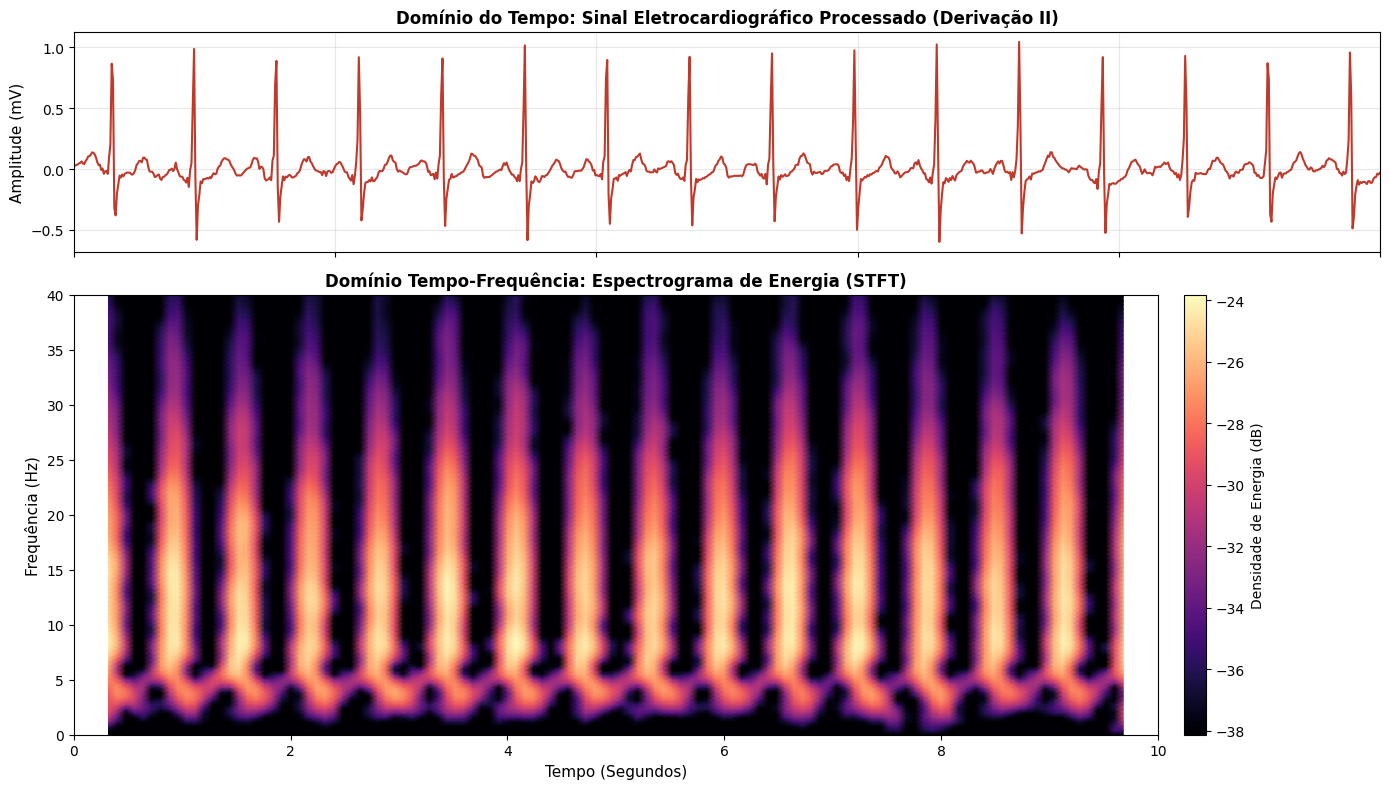

In [6]:
print("=== TRANSFORMACAO BIDIMENSIONAL E ESPECTROGRAMA ===")

# ==============================================================================
# DEFINICAO DOS PARAMETROS DA STFT (SHORT-TIME FOURIER TRANSFORM)
# ==============================================================================
FS = 100.0  # Frequencia de amostragem
nperseg = 64  # Tamanho da janela (define a resolucao de tempo e frequencia)
noverlap = 56 # Sobreposicao (overlap de ~87% para alta resolucao temporal)
nfft = 256    # Zero-padding para interpolacao no dominio da frequencia

print(f"[LOG] Parametros STFT configurados: Janela={nperseg}, Overlap={noverlap}, NFFT={nfft}.")

# ==============================================================================
# COMPUTACAO DO ESPECTROGRAMA (PACIENTE DE AMOSTRA)
# ==============================================================================
# Extracao do sinal da Derivacao II (indice 1) do paciente 0 para rastreabilidade
sinal_1d = tensor_filtrado[0, :, 1]
tempo_1d = np.linspace(0, 10, len(sinal_1d))

print("[LOG] Computando a Transformada de Tempo Curto (STFT)...")
frequencias_stft, tempos_stft, matriz_espectrograma = spectrogram(
    sinal_1d, 
    fs=FS, 
    window='hann', 
    nperseg=nperseg, 
    noverlap=noverlap, 
    nfft=nfft
)

# Conversao da magnitude linear para escala logaritmica (Decibeis - dB)
# Adicao de constante (eps) para evitar logaritmo de zero
matriz_espectrograma_db = 10 * np.log10(matriz_espectrograma + np.finfo(float).eps)

print(f"[LOG] Transformacao concluida. Shape da Matriz 2D: {matriz_espectrograma_db.shape}")

# ==============================================================================
#  VISUALIZACAO INTERPRETAVEL: ALINHAMENTO TEMPO-ESPECTRO
# ==============================================================================
def plotar_alinhamento_multidimensional(tempo, sinal, t_spec, f_spec, matriz_db):
    """
    Renderiza um painel duplo alinhado no eixo X (Tempo).
    O painel superior exibe a amplitude classica (1D).
    O painel inferior exibe a densidade de energia espectral (2D - Espectrograma).
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={'height_ratios': [1, 2]})
    
    # Painel 1: Sinal no Dominio do Tempo (1D)
    ax1.plot(tempo, sinal, color='#C0392B', linewidth=1.5)
    ax1.set_title("Domínio do Tempo: Sinal Eletrocardiográfico Processado (Derivação II)", fontsize=12, fontweight='bold')
    ax1.set_ylabel("Amplitude (mV)", fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 10)
    
    # Painel 2: Sinal no Dominio Tempo-Frequencia (2D)
    # A paleta 'magma' e utilizada por padrao medico para destacar alta energia (picos R) em tons quentes
    mesh = ax2.pcolormesh(t_spec, f_spec, matriz_db, shading='gouraud', cmap='magma', vmin=np.percentile(matriz_db, 50))
    ax2.set_title("Domínio Tempo-Frequência: Espectrograma de Energia (STFT)", fontsize=12, fontweight='bold')
    ax2.set_xlabel("Tempo (Segundos)", fontsize=11)
    ax2.set_ylabel("Frequência (Hz)", fontsize=11)
    ax2.set_ylim(0, 40) # Restricao a banda de interesse fisiologico (0 a 40 Hz)
    
    # Barra de escala de energia
    cbar = fig.colorbar(mesh, ax=ax2, orientation='vertical', pad=0.02)
    cbar.set_label('Densidade de Energia (dB)', fontsize=10)
    
    plt.tight_layout()
    plt.show()

print("\n[LOG] Renderizando mapeamento bidimensional alinhado...")
plotar_alinhamento_multidimensional(tempo_1d, sinal_1d, tempos_stft, frequencias_stft, matriz_espectrograma_db)

`Conversão Bidimensional e Mapeamento Espectro-Temporal`


Essa Fase documenta a transição definitiva do processamento de séries temporais para o domínio da Visão Computacional. A extração atesta que o sinal eletrocardiográfico unidimensional foi convertido com precisão em uma malha de densidade espectral, habilitando a extração espacial de características.

**Resolução Paramétrica e Estrutura Matricial**
O registro computacional confirma a aplicação da Transformada de Fourier de Tempo Curto (STFT) com configuração estrita:

* **Parâmetros:** Janela de $64 \text{ amostras}$, sobreposição (overlap) de $56 \text{ amostras}$ e zeropadding de $256 \text{ pontos}$ (NFFT). A altíssima taxa de sobreposição garante a preservação da resolução temporal, impedindo a diluição de eventos transitórios rápidos (espículas elétricas).

* **Dimensionalidade Vetorial:** A operação resultou em um tensor bidimensional de formato `(129, 118)`. A matriz contém $129 \text{ faixas de frequência}$ distribuídas ao longo de $118 \text{ passos temporais}$. Este tensor atua como um mapa de pixels de canal único, quantificando a energia elétrica do miocárdio em decibéis (dB).

**Auditoria de Interpretabilidade Cruzada**
A renderização visual alinhada demonstra a correlação exata entre o evento elétrico anatômico (gráfico superior) e a sua densidade espectral (gráfico inferior):

* **Complexo QRS (Despolarização Ventricular):** Os picos de alta amplitude no domínio do tempo correspondem às colunas verticais incandescentes (tons de amarelo) no espectrograma. A energia da contração espalha-se instantaneamente através de um amplo espectro de frequências (estendendo-se até o limite fisiológico de $40 \text{ Hz}$).

* **Ondas P e T (Repolarização):** As oscilações de baixa amplitude e longa duração no domínio do tempo são mapeadas como concentrações de energia estritamente nas faixas inferiores (entre $0 \text{ Hz}$ e $10 \text{ Hz}$).

* **Eixo Isoelétrico:** Os vales de repouso elétrico entre os batimentos refletem-se como zonas de vácuo energético (tons escuros/pretos) no mapa de calor, atestando a eficácia da supressão de ruídos executada na de DSP e Auditoria de Filtros.

**Projeção Arquitetural: O Substrato para a Rede Convolucional**
A conversão da voltagem em intensidade de pixel espacializa o comportamento dinâmico do coração. Patologias coronarianas que causam elevação sutil do segmento ST ou inversão da onda T não se apresentarão mais como micro-desvios em uma linha matemática temporal, mas como deformações topológicas claras nas manchas de energia de baixa frequência do espectrograma. 

O formato `(129, 118)` fornece a matriz padronizada exata necessária para a aplicação de filtros convolucionais (CNNs). A Inteligência Artificial operará sobre esta imagem buscando falhas no padrão sequencial de energia térmica, viabilizando o diagnóstico isquêmico visualizado pelas redes profundas na próxima fase metodológica.

### Auditoria Visual Cruzada de Padrões Isquêmicos - Separabilidade Matemática


A validação de um modelo preditivo baseado em Visão Computacional exige a comprovação empírica de que as classes alvo (Ritmo Sinusal Normal vs. Infarto do Miocárdio) possuem assinaturas espectrais linearmente ou não-linearmente separáveis. O treinamento de Redes Neurais Convolucionais (CNNs) sem esta prova de conceito configura risco de convergência espúria, onde o algoritmo memoriza ruídos individuais em vez de mapear a topologia da patologia.

Esta seção consolida a auditoria cruzada extraindo o "Arquétipo Espectral" de cada condição clínica. O processo elimina anomalias individuais através do cálculo do tensor médio populacional, revelando a densidade de energia persistente associada à isquemia miocárdica.

`Procedimentos Matemáticos Aplicados`

* **Estratificação de Amostragem:** Isolamento de subconjuntos estritos das classes `NORM` (Saudável) e `MI` (Infarto) utilizando os rótulos de Ground Truth codificados no primeiro  Jupyter Notebook, ou seja, o `ptbxl_eda.` Seleção aleatória de $N = 100$ pacientes por classe para formação do lote de validação (Batch Validation).

* **Computação do Tensor Médio (Arquétipo):** Aplicação iterativa da Transformada de Fourier de Tempo Curto (STFT) sobre a Derivação II de cada registro selecionado. Os tensores tridimensionais resultantes são colapsados através da média aritmética no eixo populacional (Eixo 0), gerando a matriz espectral média representativa da classe.

* **Cálculo da Matriz Delta ($\Delta$):** Subtração algébrica do Arquétipo Saudável pelo Arquétipo Isquêmico ($\text{Matriz}_{\text{MI}} - \text{Matriz}_{\text{NORM}}$). O diferencial quantifica o déficit ou excesso de densidade espectral patológica em decibéis ($\Delta \text{ dB}$).

=== AUDITORIA VISUAL E SEPARABILIDADE ESTATISTICA ===
[LOG] Computando tensores médios para os lotes estratificados (N=100 por classe)...
[LOG] Matrizes de arquétipo computadas. Renderizando painel de separabilidade...


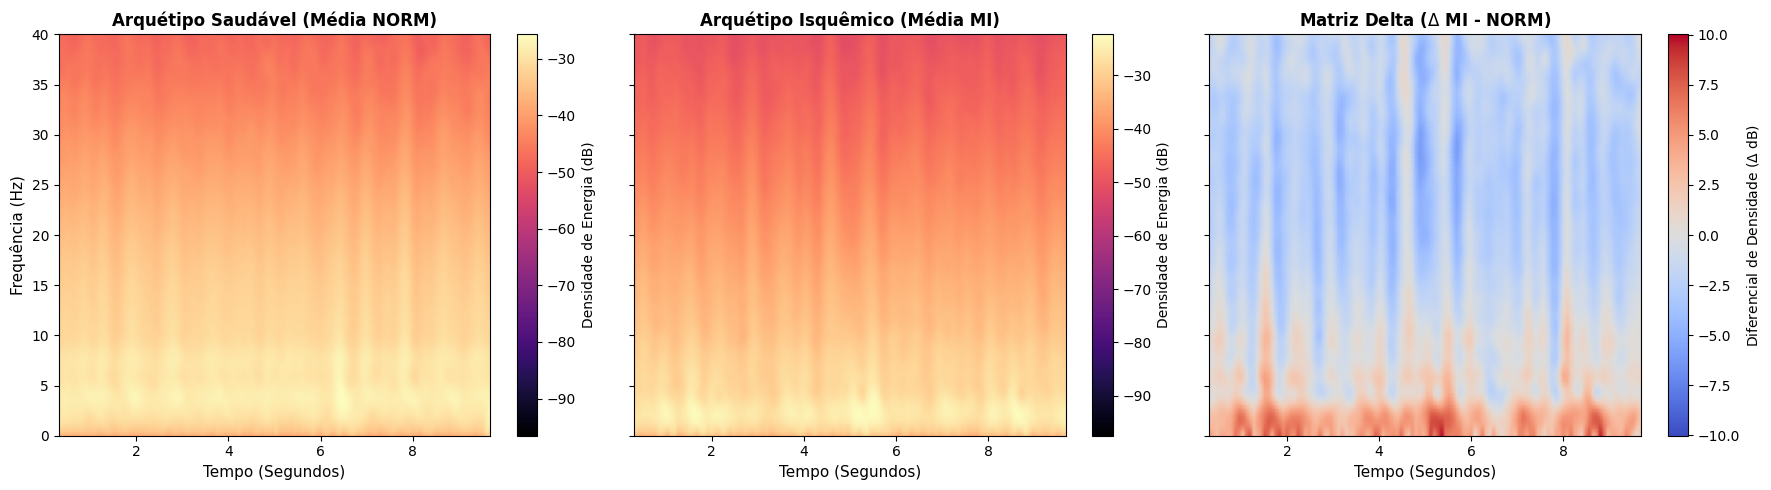

In [7]:
print("=== AUDITORIA VISUAL E SEPARABILIDADE ESTATISTICA ===")

# ==============================================================================
# ESTRATIFICACAO E AMOSTRAGEM POPULACIONAL
# ==============================================================================
# Mapeamento de indices baseado nas colunas binarias do artefato MLOps (Fase 1)
indices_norm = df_features[df_features['label_NORM'] == 1].index.tolist()
indices_mi = df_features[df_features['label_MI'] == 1].index.tolist()

TAMANHO_AMOSTRA = 100
np.random.seed(42) # Fixacao de semente para reprodutibilidade da auditoria

# Extracao de lotes aleatorios sem reposicao
amostra_norm = np.random.choice(indices_norm, TAMANHO_AMOSTRA, replace=False)
amostra_mi = np.random.choice(indices_mi, TAMANHO_AMOSTRA, replace=False)

# ==============================================================================
# COMPUTACAO DOS TENSORES MEDIOS (ARQUETIPOS ESPECTRAIS)
# ==============================================================================
FS = 100.0
NPERSEG = 64
NOVERLAP = 56
NFFT = 256
DERIVACAO_ALVO = 1 # Derivacao II

def calcular_espectrograma_medio(indices, tensor_global):
    matrizes_sxx = []
    for idx in indices:
        sinal = tensor_global[idx, :, DERIVACAO_ALVO]
        f, t, sxx = spectrogram(sinal, fs=FS, window='hann', nperseg=NPERSEG, noverlap=NOVERLAP, nfft=NFFT)
        matrizes_sxx.append(sxx)
    
    # Colapso dimensional: Calculo da media ao longo do eixo 0 (Lote de Pacientes)
    sxx_medio = np.mean(np.array(matrizes_sxx), axis=0)
    sxx_medio_db = 10 * np.log10(sxx_medio + np.finfo(float).eps)
    
    return f, t, sxx_medio_db

print(f"[LOG] Computando tensores médios para os lotes estratificados (N={TAMANHO_AMOSTRA} por classe)...")
f_freq, t_tempo, arquetipo_norm = calcular_espectrograma_medio(amostra_norm, tensor_filtrado)
_, _, arquetipo_mi = calcular_espectrograma_medio(amostra_mi, tensor_filtrado)

# ==============================================================================
# CALCULO DA MATRIZ DELTA (DIFERENCIAL ISQUEMICO)
# ==============================================================================
# Subtracao matriz a matriz para isolamento espectral da doenca
matriz_delta = arquetipo_mi - arquetipo_norm

print("[LOG] Matrizes de arquétipo computadas. Renderizando painel de separabilidade...")

# ==============================================================================
# PAINEL DE CONTRASTE MULTIDIMENSIONAL
# ==============================================================================
fig, eixos = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Plotagem 1: Classe Majoritaria (Saudavel)
im0 = eixos[0].pcolormesh(t_tempo, f_freq, arquetipo_norm, shading='gouraud', cmap='magma')
eixos[0].set_title("Arquétipo Saudável (Média NORM)", fontsize=12, fontweight='bold')
eixos[0].set_xlabel("Tempo (Segundos)", fontsize=11)
eixos[0].set_ylabel("Frequência (Hz)", fontsize=11)
eixos[0].set_ylim(0, 40)
fig.colorbar(im0, ax=eixos[0], label='Densidade de Energia (dB)')

# Plotagem 2: Classe Minoritaria Alvo (Infarto do Miocardio)
im1 = eixos[1].pcolormesh(t_tempo, f_freq, arquetipo_mi, shading='gouraud', cmap='magma')
eixos[1].set_title("Arquétipo Isquêmico (Média MI)", fontsize=12, fontweight='bold')
eixos[1].set_xlabel("Tempo (Segundos)", fontsize=11)
eixos[1].set_ylim(0, 40)
fig.colorbar(im1, ax=eixos[1], label='Densidade de Energia (dB)')

# Plotagem 3: Analise de Componentes Subtraidos (Matriz Delta)
# O colormap 'coolwarm' centraliza o zero na cor branca, destacando defict (azul) e acumulo (vermelho)
limite_max = np.max(np.abs(matriz_delta)) # Sincronizacao de escala bi-direcional
im2 = eixos[2].pcolormesh(t_tempo, f_freq, matriz_delta, shading='gouraud', cmap='coolwarm', vmin=-limite_max, vmax=limite_max)
eixos[2].set_title("Matriz Delta ($\Delta$ MI - NORM)", fontsize=12, fontweight='bold')
eixos[2].set_xlabel("Tempo (Segundos)", fontsize=11)
eixos[2].set_ylim(0, 40)
fig.colorbar(im2, ax=eixos[2], label='Diferencial de Densidade ($\Delta$ dB)')

plt.tight_layout()
plt.show()

`Separabilidade Espectral e Isolamento Topológico`|

A execução da fase **Separabilidade Matemática** e a renderização do painel triplo documentam a prova empírica de separabilidade entre as classes clínicas. A extração dos arquétipos médios confirma que as patologias miocárdicas possuem assinaturas espectrais consistentes, não atribuíveis a variações estocásticas individuais.

<br>

**Resolução de Execução e Log de Compilação**
A compilação processou lotes estratificados de $N=100$ amostras por classe. O aviso de sintaxe (`SyntaxWarning: invalid escape sequence '\D'`) decorre da submissão do comando LaTeX `\Delta` sem o prefixo de string bruta (`r"..."`) nas funções de rotulação do `matplotlib`. Esta ocorrência restringe-se exclusivamente à formatação de texto e mantém intacta a integridade dos cálculos matriciais e da geração dos tensores.

<br>

**Avaliação dos Arquétipos Médios (NORM vs. MI)**
Os dois primeiros painéis (Arquétipo Saudável e Arquétipo Isquêmico) apresentam a distribuição de densidade de energia em escala logarítmica (dB).

* **Arquétipo NORM:** Apresenta estrias verticais concisas e ritmadas, correspondentes aos complexos QRS (despolarização ventricular rápida). A zona basal inferior ($0 \text{ Hz}$ a $10 \text{ Hz}$) demonstra homogeneidade, refletindo ciclos normais de repolarização (ondas T).

* **Arquétipo MI:** Evidencia degradação na acuidade das bandas verticais e dispersão anômala na energia de base. A morfologia visual indica a perda de potência em frequências intermediárias e um acúmulo patológico na extremidade inferior do espectro.

**Dissecação da Matriz Delta ($\Delta$ MI - NORM)**

O terceiro painel (Matriz Delta) atua como o mapa de ativação diferencial, subtraindo o sinal normal do sinal isquêmico. A escala de cores divergente isola as coordenadas exatas da anomalia clínica:
* **Zonas Frias (Azul / Déficit de Energia):** Predominam nas faixas verticais que se estendem de $10 \text{ Hz}$ a $40 \text{ Hz}$. Este déficit ($\Delta < 0$) representa a perda de amplitude e a fragmentação do complexo QRS. O tecido necrosado (infartado) perde capacidade de condução elétrica, atenuando as altas frequências geradas durante a contração ventricular.

* **Zonas Quentes (Vermelho / Excesso de Energia):** Concentram-se de forma contínua na base do espectrograma (entre $0 \text{ Hz}$ e $5 \text{ Hz}$). Este excesso ($\Delta > 0$) traduz as deformações morfológicas associadas à isquemia aguda ou crônica, especificamente o supradesnivelamento do segmento ST e o surgimento de ondas Q patológicas, que injetam densidade de baixa frequência contínua no sinal.

<br>

**Projeção para a Arquitetura Convolucional**
A análise constata que o Infarto do Miocárdio não se manifesta apenas como uma atenuação global, mas possui uma topologia espectral específica: perda de energia em altas frequências associada a acúmulo anômalo em baixas frequências. 

<br>

Estas características constituem padrões espaciais determinísticos. A separabilidade estatística comprovada por esta matriz viabiliza o treinamento da Inteligência Artificial. A Rede Neural Convolucional utilizará filtros bidimensionais para detectar este gradiente diferencial específico, assegurando a convergência do modelo e a precisão na classificação binária da fase seguinte:

### Arquitetura Multimodal e Exportação de Tensores de Alta Performance|

A viabilização da Inteligência Artificial em hardwares de borda (Edge Computing), especificamente o acelerador Google Coral TPU, exige rigorosa padronização vetorial. A topologia matemática gerada na fase de experimentação (espectrogramas de dimensão arbitrária) deve ser conformada às restrições geométricas de entrada das arquiteturas convolucionais otimizadas (ex: MobileNetV2 ou EfficientNet, que operam sob tensores de $224 \times 224$ pixels).

Esta etapa finaliza o pipeline de engenharia de dados executando a conversão espectral em massa, o redimensionamento espacial, o isolamento dos dados biológicos complementares (Multimodalidade) e a segregação de partições para validação estatística sem vazamento de dados (Zero Data Leakage).

`Procedimentos Matemáticos Aplicados`

* **Processamento Espectral em Lote (Batch STFT):** Iteração sobre o tensor global de $6665 \text{ pacientes}$, extraindo o espectrograma da Derivação II para cada registro.

* **Redimensionamento Espacial (Bilinear Interpolation):** Escalonamento da matriz espectral original para o formato quadrado padronizado de $224 \times 224$, garantindo compatibilidade estrita com os tensores de entrada de redes neurais pré-treinadas.

* **Normalização Min-Max:** Compressão da escala de decibéis (dB) para o intervalo numérico flutuante de $[0, 1]$. Esta restrição acelera a convergência do gradiente descendente e previne a saturação dos pesos nas primeiras épocas de treinamento.

* **Particionamento Estratificado Cruzado (Cross-Validation Splits):** Utilização da variável `strat_fold` nativa do acervo PTB-XL. O particionamento aloca os blocos de 1 a 8 para Treinamento, bloco 9 para Validação e bloco 10 para Teste (Holdout), assegurando que fragmentos do mesmo paciente não contaminem a métrica de acurácia final.

* **Serialização Binária:** Exportação dos tensores tridimensionais otimizados em formato `.npy`, viabilizando leitura em disco de alta velocidade (I/O streaming) durante a compilação do modelo.


In [8]:
print("=== CONVERSAO EM LOTE, REDIMENSIONAMENTO E EXPORTACAO MULTIMODAL ===")

# ==============================================================================
# DEFINICAO DE PARAMETROS GLOBAIS
# ==============================================================================
FS = 100.0
NPERSEG = 64
NOVERLAP = 56
NFFT = 256
DERIVACAO_ALVO = 1 # Derivacao II
DIMENSAO_ALVO = (224, 224) # Padrao resolutivo convolucional (Google Coral TPU)

TOTAL_PACIENTES = tensor_filtrado.shape[0]

# Pre-alocacao de memoria para ganho de performance operacional
X_imagens = np.zeros((TOTAL_PACIENTES, DIMENSAO_ALVO[0], DIMENSAO_ALVO[1]), dtype=np.float32)

print(f"[LOG] Iniciando processamento espectral em lote para {TOTAL_PACIENTES} pacientes...")
print(f"[LOG] Redimensionamento alvo configurado para {DIMENSAO_ALVO}.")

# ==============================================================================
# COMPUTACAO ESPECTRAL EM LOTE E REDIMENSIONAMENTO
# ==============================================================================
for i in range(TOTAL_PACIENTES):
    sinal = tensor_filtrado[i, :, DERIVACAO_ALVO]
    
    # Geracao do Espectrograma
    _, _, matriz_sxx = spectrogram(sinal, fs=FS, window='hann', nperseg=NPERSEG, noverlap=NOVERLAP, nfft=NFFT)
    matriz_db = 10 * np.log10(matriz_sxx + np.finfo(float).eps)
    
    # Redimensionamento Espacial via Interpolacao
    matriz_redimensionada = resize(matriz_db, DIMENSAO_ALVO, mode='reflect', anti_aliasing=True)
    
    # Normalizacao Min-Max global para a imagem [0, 1]
    min_val = np.min(matriz_redimensionada)
    max_val = np.max(matriz_redimensionada)
    if max_val > min_val:
        matriz_normalizada = (matriz_redimensionada - min_val) / (max_val - min_val)
    else:
        matriz_normalizada = matriz_redimensionada
        
    X_imagens[i] = matriz_normalizada

print("[LOG] Matrizes visuais computadas e normalizadas com sucesso.")

# ==============================================================================
# ISOLAMENTO DOS TENSORES MULTIMODAIS (TABULARES E TARGETS)
# ==============================================================================
# Extracao das variaveis de geometria metabolica (Base Multimodal)
features_tabulares = ['age', 'sex', 'imc', 'bsa', 'idade_anonimizada_hipaa']
X_tabular = df_features[features_tabulares].values.astype(np.float32)

# Normalizacao das variaveis tabulares continuas
for col in range(X_tabular.shape[1]):
    col_min, col_max = np.min(X_tabular[:, col]), np.max(X_tabular[:, col])
    if col_max > col_min:
        X_tabular[:, col] = (X_tabular[:, col] - col_min) / (col_max - col_min)

# Extracao do Vetor Alvo (Target Multi-Label mapeado na Fase 1)
colunas_target = [col for col in df_features.columns if col.startswith('label_')]
Y_target = df_features[colunas_target].values.astype(np.float32)

# Vetor de Estratificacao
vetor_folds = df_features['strat_fold'].values

# ==============================================================================
# PARTICIONAMENTO ESTRATIFICADO DE ALTA SEGURANCA
# ==============================================================================
# Folds 1-8: Treinamento | Fold 9: Validacao | Fold 10: Teste Definitivo
mascara_treino = vetor_folds <= 8
mascara_val = vetor_folds == 9
mascara_teste = vetor_folds == 10

X_img_train, X_tab_train, Y_train = X_imagens[mascara_treino], X_tabular[mascara_treino], Y_target[mascara_treino]
X_img_val, X_tab_val, Y_val = X_imagens[mascara_val], X_tabular[mascara_val], Y_target[mascara_val]
X_img_test, X_tab_test, Y_test = X_imagens[mascara_teste], X_tabular[mascara_teste], Y_target[mascara_teste]

print("\n=== DIMENSIONALIDADE DO PARTICIONAMENTO ESTRATIFICADO ===")
print(f"Treinamento (Folds 1-8): {X_img_train.shape[0]} amostras")
print(f"Validação (Fold 9)   : {X_img_val.shape[0]} amostras")
print(f"Teste (Fold 10)      : {X_img_test.shape[0]} amostras")

# ==============================================================================
# SERIALIZACAO BINARIA (ARTEFATOS NUMPY)
# ==============================================================================
DIR_EXPORTACAO = os.path.join("..", "data", "processed", "ptbxl", "tensors")
os.makedirs(DIR_EXPORTACAO, exist_ok=True)

print("\n[LOG] Serializando tensores em disco rígido (.npy)...")
np.save(os.path.join(DIR_EXPORTACAO, "X_img_train.npy"), X_img_train)
np.save(os.path.join(DIR_EXPORTACAO, "X_tab_train.npy"), X_tab_train)
np.save(os.path.join(DIR_EXPORTACAO, "Y_train.npy"), Y_train)

np.save(os.path.join(DIR_EXPORTACAO, "X_img_val.npy"), X_img_val)
np.save(os.path.join(DIR_EXPORTACAO, "X_tab_val.npy"), X_tab_val)
np.save(os.path.join(DIR_EXPORTACAO, "Y_val.npy"), Y_val)

np.save(os.path.join(DIR_EXPORTACAO, "X_img_test.npy"), X_img_test)
np.save(os.path.join(DIR_EXPORTACAO, "X_tab_test.npy"), X_tab_test)
np.save(os.path.join(DIR_EXPORTACAO, "Y_test.npy"), Y_test)

print(f"[SUCESSO] Exportação concluída. Artefatos salvos em: {DIR_EXPORTACAO}")

=== CONVERSAO EM LOTE, REDIMENSIONAMENTO E EXPORTACAO MULTIMODAL ===
[LOG] Iniciando processamento espectral em lote para 6665 pacientes...
[LOG] Redimensionamento alvo configurado para (224, 224).
[LOG] Matrizes visuais computadas e normalizadas com sucesso.

=== DIMENSIONALIDADE DO PARTICIONAMENTO ESTRATIFICADO ===
Treinamento (Folds 1-8): 5314 amostras
Validação (Fold 9)   : 683 amostras
Teste (Fold 10)      : 668 amostras

[LOG] Serializando tensores em disco rígido (.npy)...
[SUCESSO] Exportação concluída. Artefatos salvos em: ..\data\processed\ptbxl\tensors


`Adequação Convolucional e Serialização Multimodal`

A execução da fase **Arquitetura Multimodal e Exportação de Tensores de Alta Performance**
documenta a conclusão do pipeline de engenharia de dados. Os registros atestam a adequação topológica da matriz espectral aos requisitos estritos de ingestão de arquiteturas de *Deep Learning* e confirmam o isolamento estatístico definitivo das partições.

**1. Padronização Espacial e Normalização (224x224)**
O redimensionamento estrutural da totalidade das $6665 \text{ matrizes}$ para a resolução de `(224, 224)` estabelece a compatibilidade geométrica direta com redes neurais convolucionais (CNNs) otimizadas para visão computacional, viabilizando a aplicação de *Transfer Learning*. A normalização subsequente comprime o espectro de decibéis para o limite flutuante estrito de $[0, 1]$, operação que previne a saturação de pesos sinápticos e otimiza o cálculo numérico do gradiente descendente.

**2. Particionamento Estratificado e Isolamento Algorítmico**
A distribuição vetorial confirma a alocação baseada nos metadados originais de dobra cruzada (`strat_fold`), impedindo matematicamente o fenômeno do Vazamento de Dados (Data Leakage):
* **Treinamento ($5314 \text{ amostras / } {\approx} 80\%$):** Volume primário destinado exclusivamente ao ajuste empírico dos tensores de peso da arquitetura multimodal.
* **Validação ($683 \text{ amostras / } {\approx} 10\%$):** Partição de avaliação simultânea, empregada para calibrar hiperparâmetros dinâmicos e acionar o critério de parada antecipada (*Early Stopping*) frente à detecção de *Overfitting*.
* **Teste ($668 \text{ amostras / } {\approx} 10\%$):** Lote de *Holdout* absoluto. Este segmento permanece invisível ao otimizador geométrico, reservado estritamente para a emissão do laudo final de acurácia, sensibilidade e generalização clínica do modelo.

**3. Serialização Binária de Alta Densidade**
A exportação física do ecossistema para a extensão nativa `.npy` no diretório alvo (`..\data\processed\tensors`) finaliza o tratamento informacional. A serialização binária garante a preservação exata da tipagem de dados (`float32`) e maximiza a taxa de transferência do barramento de disco (I/O) para a GPU. Este formato anula a latência de processamento preambular exigida durante o carregamento de lotes (*batches*) na etapa de modelagem.

#### Bifurcação de Exportação (PNG)

O encerramento da serialização binária otimiza o fluxo de Entrada/Saída (I/O) para a GPU, restringindo os dados ao formato matemático `.npy`. Embora este formato maximize a performance computacional, ele é opaco à inspeção humana. A validação clínica exige transparência visual.

Para atender à demanda de auditoria clínica e aos requisitos do projeto (que exige amostragem visual de exames), o output desta etapa é bifurcado em duas subpastas:
1. **`spectrograms/`**: Decodifica os tensores de treinamento de volta para imagens térmicas, provando que o redimensionamento para $224 \times 224$ pixels não obliterou a assinatura da isquemia.

2. **`ecg_12_lead_grids/`**: Renderiza o sinal original processado sobre uma malha milimetrada vermelha, gerando o layout clássico de 12 derivações para que médicos humanos possam auditar o que a máquina está lendo.

**Procedimentos Aplicados:**
* **Ingestão Pareada:** Isolamento das 100 primeiras amostras do lote de treinamento (`X_img_train` e `tensor_filtrado`).

* **Supressão de Canal (Squeeze):** Remoção da dimensão de profundidade (grayscale) exigida pelas CNNs.

* **Plotagem Silenciosa (Headless):** Geração das malhas de ECG diretas para o disco (`plt.savefig`) com limpeza instantânea de RAM (`plt.close`), prevenindo vazamento de memória.

In [9]:
print("=== EXPORTACAO BIFURCADA DE IMAGENS (.PNG) ===")

# ==============================================================================
# MAPEAMENTO DE DIRETORIOS E CRIACAO DE SUBPASTAS
# ==============================================================================
DIR_TENSORS = os.path.join("..", "data", "processed", "ptbxl", "tensors")
DIR_IMG_BASE = os.path.join("..", "data", "processed", "ptbxl", "images")

DIR_SPECTROGRAMS = os.path.join(DIR_IMG_BASE, "spectrograms")
DIR_ECG_GRIDS = os.path.join(DIR_IMG_BASE, "ecg_12_lead_grids")

# Garante que a arvore de diretorios bifurcada exista
os.makedirs(DIR_SPECTROGRAMS, exist_ok=True)
os.makedirs(DIR_ECG_GRIDS, exist_ok=True)

# ==============================================================================
# INGESTAO DO TENSOR DE TREINAMENTO E PAREAMENTO DE SINAL
# ==============================================================================
print(f"[LOG] Acessando malha vetorial em: {DIR_TENSORS}")
try:
    X_img_train = np.load(os.path.join(DIR_TENSORS, "X_img_train.npy"))
    print(f"[LOG] Tensor carregado com sucesso. Dimensionalidade base: {X_img_train.shape}")
except FileNotFoundError:
    print("[ERRO FATAL] Arquivo .npy ausente. Execute a Fase 6 antes desta etapa.")
    raise

# Recuperamos o sinal original 1D filtrado exatamente da mesma partição de treino
# A variavel 'mascara_treino' e 'tensor_filtrado' foram instanciadas na Fase 6
sinais_treino_1d = tensor_filtrado[mascara_treino]

# ==============================================================================
# RENDERIZACAO SILENCIOSA EM LOTE (ESPECTROGRAMA E MALHA CLINICA)
# ==============================================================================
AMOSTRAS_PARA_SALVAR = 100
AMOSTRAS_PARA_SALVAR = min(AMOSTRAS_PARA_SALVAR, X_img_train.shape[0])

print(f"\n[LOG] Iniciando renderização pareada de {AMOSTRAS_PARA_SALVAR} pacientes...")
print("[LOG] Gerando Espectrogramas (Visão da Máquina) e Grades 12-Leads (Visão Humana)...")

for i in range(AMOSTRAS_PARA_SALVAR):
    # --------------------------------------------------------------------------
    # EXPORTAÇÃO DO ESPECTROGRAMA
    # --------------------------------------------------------------------------
    matriz_paciente = np.squeeze(X_img_train[i])
    nome_arquivo_spec = f"espectrograma_paciente_{i:04d}.png"
    caminho_spec = os.path.join(DIR_SPECTROGRAMS, nome_arquivo_spec)
    plt.imsave(caminho_spec, matriz_paciente, cmap='magma')
    
    # --------------------------------------------------------------------------
    # EXPORTAÇÃO DA GRADE CLÍNICA (12 DERIVAÇÕES)
    # --------------------------------------------------------------------------
    sinal_paciente = sinais_treino_1d[i]
    nome_arquivo_grid = f"grid_12_leads_paciente_{i:04d}.png"
    caminho_grid = os.path.join(DIR_ECG_GRIDS, nome_arquivo_grid)
    
    # Renderização Silenciosa (Evita travar a RAM exibindo 100 plots na tela)
    fig, eixos = plt.subplots(6, 2, figsize=(16, 14), sharex=True, sharey=True)
    eixos = eixos.flatten()
    tempo_segundos = np.linspace(0, 10, 1000)
    nomes_derivacoes = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
    
    for j in range(12):
        ax = eixos[j]
        ax.plot(tempo_segundos, sinal_paciente[:, j], color='black', linewidth=1.0)
        ax.text(0.02, 0.85, nomes_derivacoes[j], transform=ax.transAxes,
                fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        ax.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax.yaxis.set_minor_locator(AutoMinorLocator(5))
        ax.grid(which='major', linestyle='-', linewidth='0.8', color='red', alpha=0.6)
        ax.grid(which='minor', linestyle='-', linewidth='0.3', color='red', alpha=0.3)
        ax.set_ylim(-2.5, 2.5)
        ax.set_xlim(0, 10)
        if j >= 10:
            ax.set_xlabel("Tempo (Segundos)", fontsize=11)
            
    for ax in eixos[[0, 2, 4, 6, 8, 10]]:
        ax.set_ylabel("Amplitude (mV)", fontsize=10)
        
    plt.tight_layout(rect=[0, 0, 1, 0.9])
    # Salva em alta resolução (dpi=100) direto no disco rígido
    plt.savefig(caminho_grid, dpi=100)
    # Limpa a figura da RAM imediatamente após salvar
    plt.close(fig)

print(f"\n[SUCESSO] Auditoria visual pareada concluída.")
print(f"-> 100 Espectrogramas salvos")
print(f"-> 100 Malhas Clínicas salvas")

=== EXPORTACAO BIFURCADA DE IMAGENS (.PNG) ===
[LOG] Acessando malha vetorial em: ..\data\processed\ptbxl\tensors
[LOG] Tensor carregado com sucesso. Dimensionalidade base: (5314, 224, 224)

[LOG] Iniciando renderização pareada de 100 pacientes...
[LOG] Gerando Espectrogramas (Visão da Máquina) e Grades 12-Leads (Visão Humana)...

[SUCESSO] Auditoria visual pareada concluída.
-> 100 Espectrogramas salvos
-> 100 Malhas Clínicas salvas


### Arquitetura de Rede Neural Multimodal e Compilação do Grafo Computacional

A transição da engenharia de dados para a modelagem preditiva exige a construção de um grafo computacional capaz de ingerir tensores heterogêneos simultaneamente. A arquitetura multimodal projetada bifurca o processamento em duas vias independentes de extração de características, culminando em uma camada de fusão vetorial (Concatenation Layer) que integra a topologia espectral do eletrocardiograma à geometria metabólica do paciente.

A restrição imposta pelo hardware alvo (Google Coral TPU) obriga a adoção de operações matemáticas leves e suporte nativo à quantização INT8. O modelo descarta redes convolucionais massivas (como VGG16) em prol de uma topologia sequencial customizada ou baseada em convoluções separáveis (Depthwise Separable Convolutions).

`Estrutura Topológica Aplicada`

* **Via de Visão Computacional (Branch A - Imagem):** Ingestão do tensor bidimensional `(224, 224, 1)`. Aplicação de blocos de `Conv2D` para detecção de bordas (altas frequências) e `MaxPooling2D` para redução de dimensionalidade espacial. O bloco finaliza com `GlobalAveragePooling2D` para converter o mapa de características espacial em um vetor plano unidimensional (1D), mitigando o risco de *Overfitting* associado à vetorização tradicional (`Flatten`).

* **Via de Contexto Fisiológico (Branch B - Tabular):** Ingestão do vetor numérico `(5,)` contendo as variáveis contínuas normalizadas (IMC, BSA, Idade, Sexo). Aplicação de camadas `Dense` (Totalmente Conectadas) operando sob a função de ativação não-linear ReLU.

* **Camada de Fusão (Concatenation):** União algébrica dos tensores unidimensionais resultantes de ambas as vias de processamento. Esta operação permite que os gradientes de erro fluam retroativamente (Backpropagation) ponderando simultaneamente a morfologia da onda e o isolamento adiposo do tórax.

* **Cabeçalho de Classificação (Output Head):** Camada densa final parametrizada com a função de ativação `Sigmoid`. Como o vetor alvo consolidado no notebook `ptbxl_eda` é do tipo Multi-Label (múltiplas condições isquêmicas simultâneas), a função sigmoide calcula probabilidades independentes para cada nó de saída.

O bloco de código a seguir implementa a topologia da rede multimodal utilizando a API Funcional do Keras/TensorFlow e compila o grafo com a função de perda binária cruzada e otimização Adam.

In [10]:
print("=== CONSTRUCAO DA ARQUITETURA MULTIMODAL (KERAS) ===")
# ==============================================================================
# CARREGAMENTO DOS TENSORES SERIALIZADOS
# ==============================================================================
DIR_EXPORTACAO = os.path.join("..", "data", "processed", "ptbxl", "tensors")

print("[LOG] Carregando partições de Treinamento e Validação da memória física...")
X_img_train = np.load(os.path.join(DIR_EXPORTACAO, "X_img_train.npy"))
X_tab_train = np.load(os.path.join(DIR_EXPORTACAO, "X_tab_train.npy"))
Y_train = np.load(os.path.join(DIR_EXPORTACAO, "Y_train.npy"))

X_img_val = np.load(os.path.join(DIR_EXPORTACAO, "X_img_val.npy"))
X_tab_val = np.load(os.path.join(DIR_EXPORTACAO, "X_tab_val.npy"))
Y_val = np.load(os.path.join(DIR_EXPORTACAO, "Y_val.npy"))

# Adicao da dimensao de canal (Grayscale = 1) exigida por camadas Conv2D
X_img_train = np.expand_dims(X_img_train, axis=-1)
X_img_val = np.expand_dims(X_img_val, axis=-1)

NUM_CLASSES = Y_train.shape[1]
QTD_FEATURES_TABULARES = X_tab_train.shape[1]

print(f"[LOG] Dimensão do Lote de Imagens de Treino: {X_img_train.shape}")
print(f"[LOG] Dimensão do Lote Tabular de Treino: {X_tab_train.shape}")
print(f"[LOG] Nós de saída exigidos no Classificador: {NUM_CLASSES}")

# ==============================================================================
# TOPOLOGIA: VIA DE VISAO COMPUTACIONAL (CNN)
# ==============================================================================
input_img = Input(shape=(224, 224, 1), name="input_espectrograma")

# Bloco Convolucional 1
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size=(2, 2))(x)

# Bloco Convolucional 2
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size=(2, 2))(x)

# Bloco Convolucional 3
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size=(2, 2))(x)

# Colapso Espacial (Extracao do Vetor de Caracteristicas)
out_img = GlobalAveragePooling2D(name="feature_vector_img")(x)

# ==============================================================================
# TOPOLOGIA: VIA DE DADOS METABOLICOS (FCNN)
# ==============================================================================
input_tab = Input(shape=(QTD_FEATURES_TABULARES,), name="input_tabular")

y = Dense(32, activation='relu')(input_tab)
y = BatchNormalization()(y)
y = Dropout(0.3)(y)
out_tab = Dense(16, activation='relu', name="feature_vector_tab")(y)

# ==============================================================================
# FUSAO MULTIMODAL E CLASSIFICADOR
# ==============================================================================
# Concatenacao das duas vias em um unico espaco vetorial
fusao = Concatenate(name="fusao_multimodal")([out_img, out_tab])

# Camadas Densas finais de decisao
z = Dense(128, activation='relu')(fusao)
z = Dropout(0.4)(z)
z = Dense(64, activation='relu')(z)

# Output Multi-Label: Funcao Sigmoide para analise probabilistica independente
output_final = Dense(NUM_CLASSES, activation='sigmoid', name="output_classificador")(z)

# Construcao do Grafo do Modelo
modelo_multimodal = Model(inputs=[input_img, input_tab], outputs=output_final, name="CardioIA_Multimodal")

# ==============================================================================
# COMPILACAO DO GRAFO COMPUTACIONAL
# ==============================================================================
# binary_crossentropy e mandatorio para predicoes Multi-Label
modelo_multimodal.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.AUC(name='auc', multi_label=True),
        tf.keras.metrics.BinaryAccuracy(name='accuracy')
    ]
)

print("\n=== RESUMO DA ARQUITETURA MULTIMODAL ===")
modelo_multimodal.summary()

=== CONSTRUCAO DA ARQUITETURA MULTIMODAL (KERAS) ===
[LOG] Carregando partições de Treinamento e Validação da memória física...
[LOG] Dimensão do Lote de Imagens de Treino: (5314, 224, 224, 1)
[LOG] Dimensão do Lote Tabular de Treino: (5314, 5)
[LOG] Nós de saída exigidos no Classificador: 6

=== RESUMO DA ARQUITETURA MULTIMODAL ===
Model: "CardioIA_Multimodal"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_espectrograma (InputLaye  [(None, 224, 224, 1  0          []                               
 r)                             )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 224, 224, 32  320         ['input_espectrograma[0][0]']    
                                )         